In [10]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

!pip install colorspacious


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [102 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,154 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,524 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:14 http://arch

In [11]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "DejaVu Serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11,          # mismo tamaño que \documentclass[11pt]{article}
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

In [12]:
from cycler import cycler

plt.rcParams["axes.prop_cycle"] = cycler(color=[
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#F0E442", "#000000"
])

# Fiat-Shamir: ¿qué tan aleatorio es el reto? Un análisis con Monte Carlo
**Trabajo Final — Programación Científica 2026-1**

Integrantes:\
Delgado Ortiz, David \
Fonseca Aldana, Miguel Angel\
Moreno Ceballos, Jose Daniel\
Ospina Ocampo, Juan Diego\
Urrutia Manyoma, Haison



##  Contexto teórico

El protocolo de **Fiat-Shamir** permite a un **Prover** convencer a un **Verifier** de que conoce un secreto \(s\) sin revelarlo.

Originalmente, es un protocolo **interactivo** que consta de tres pasos:

1. **Compromiso (Commitment):**

   $$
   x = r^2 \pmod{N}
   $$

2. **Reto (Challenge):**

   $$
   e \in \{0,1\}
   $$

3. **Respuesta (Response):**

   $$
   y = r \cdot s^e \pmod{N}
   $$

### La transformación de Fiat-Shamir (1986)

En lugar de que el **Verifier** elija el reto, éste se calcula como

$$
e = H(x),
$$

donde \(H\) es una función hash criptográfica.

Esta transformación elimina la necesidad de interacción entre el **Prover** y el **Verifier**, convirtiendo el protocolo de identificación en un **esquema de firma digital**.


### ¿Por qué es seguro el protocolo? El rol del reto $e \in \{0,1\}$

Sea $N = p \cdot q$ el producto de dos primos, y $v = s^2 \bmod N$ el valor público asociado
al secreto $s$. La seguridad de Fiat-Shamir descansa en un hecho estructural: **si alguien
logra encontrar dos raíces cuadradas distintas y no triviales de $v$ módulo $N$, puede
factorizar $N$**, lo cual es computacionalmente inviable (NP-completo) para $N$ suficientemente grande.


#### El protocolo, ronda por ronda

1. **Compromiso:** Alice elige $r$ aleatorio (nuevo en cada ronda) y calcula
   $$x = r^2 \bmod N$$

2. **Reto:** Bob (o el hash, en la versión no interactiva) elige $e \in \{0,1\}$

3. **Respuesta:**
   - si $e=0$: Alice manda $y = r$, y Bob verifica $y^2 \equiv x \pmod N$
   - si $e=1$: Alice manda $y = r \cdot s \bmod N$, y Bob verifica $y^2 \equiv x \cdot v \pmod N$

Nótese que solo la rama $e=1$ involucra el secreto $s$. La rama $e=0$ únicamente confirma
que Alice conocía el $r$ usado al comprometerse.

#### Por qué un impostor no puede responder a ambos retos

Un impostor que **no conoce $s$** puede intentar hacer trampa invirtiendo el orden de
construcción: en vez de generar $x=r^2$ primero, elige un $y$ arbitrario y despeja

$$x \equiv y^2 \cdot v^{-1} \pmod N$$

Con este $x$ "preparado", el impostor **sí** puede responder correctamente si Bob pide
$e=1$ (manda el $y$ que ya tenía). Pero si Bob pide $e=0$, necesitaría una raíz cuadrada
de ese mismo $x$ — y encontrarla es tan difícil como el problema original de raíces
cuadradas módulo $N$, del que depende toda la seguridad del esquema.

#### Probabilidad de éxito de un impostor

Como el impostor debe adivinar de antemano cuál reto le tocará, su probabilidad de éxito en una
ronda es $1/2$, y cae a $2^{-k}$ al repetir el protocolo $k$ veces de forma independiente.

## Implementación del protocolo Fiat-Shamir

### Configuración: generación de N = p·q y del secreto

Como se describió en el contexto teórico, se generan los parámetros del protocolo:

- Módulo público: $N = p \cdot q$, con p y q primos
- Clave privada: $s$, coprima con $N$.
- Clave pública:
  $$
  v \equiv s^2 \pmod N.
  $$
- Reto no interactivo mediante la heurística de Fiat-Shamir:
  $$
  e = H(x) \bmod 2.
  $$

In [13]:
#Importación de librerías
import numpy as np
import hashlib
import time
import secrets
import math
from sympy import randprime

# Nota: usamos `secrets` para generar valores criptográficamente sensibles
# (el nonce r y la selección del secreto s), ya que `random` no es seguro para criptografía.
# `sympy.randprime` se usa para generar los primos p, q (uso matemático, no crítico en este contexto).
# La aritmética modular usa `pow(base, exp, mod)`, optimizada en C (exponenciación binaria).

In [14]:

def generar_parametros(bits=512):
    """Genera las claves pública y privada para el protocolo Fiat-Shamir.

    Parámetros:
    - bits (int): Tamaño total deseado para el módulo N.

    Retorna:
    - dict: Diccionario con el módulo N, clave secreta s y clave pública v.
    """
    # 1. Generar dos primos grandes p y q de tamaño bits/2
    mitad_bits = bits // 2
    p = randprime(2 ** (mitad_bits - 1), 2**mitad_bits)
    q = randprime(2 ** (mitad_bits - 1), 2**mitad_bits)

    while p == q: #no permitir que p y q sean iguales
        q = randprime(2 ** (mitad_bits - 1), 2**mitad_bits)

    N = p * q

    # 2. Seleccionar clave secreta 's' tal que mcd(s, N) == 1
    while True:
        s = secrets.randbelow(N - 2) + 2
        if math.gcd(s, N) == 1:
            break

    # 3. Calcular clave pública v = s^2 mod N
    v = pow(s, 2, N)

    return {"N": N, "s": s, "v": v}


def calcular_reto_fiat_shamir(compromiso):
    """Heurística de Fiat-Shamir: Reemplaza al Verificador calculando el reto e =

    H(x) mod 2 a partir del compromiso 'x'

    Parámetros:
    compromiso: El compromiso generado por el Proponente.

    Retorna:
    int: El reto e (0 o 1) calculado.
    """
    # Convertir el compromiso a bytes para la función hash SHA-256
    x_bytes = str(compromiso).encode("utf-8")
    hash_digest = hashlib.sha256(x_bytes).hexdigest()

    # Mapear el hash a un bit {0, 1}
    e = int(hash_digest, 16) % 2
    return e


params = generar_parametros(bits=512)
print("=== Parámetros Generados ===")
print(f"Módulo N ({params['N'].bit_length()} bits): {params['N']}")
print(f"Clave secreta (s): {params['s']}")
print(f"Clave pública (v): {params['v']}")


=== Parámetros Generados ===
Módulo N (511 bits): 6430273391033129504528197221887526004494813888914952998978682734402945008124620847144461666569070347129385905705312527049592470328624075957283639383370993
Clave secreta (s): 1528137414996087168574609909621784646318098521202834943880465358726828187984432064759308360465805246066599736847096150005865535229455784561211245555937992
Clave pública (v): 3448719115186896415387827233150122387995566067369273789999755199952968914334586615684245042693362621431556342075827262472045962491983829542780270078833624


### Prover: compromiso y respuesta


El Prover genera un valor efímero aleatorio $r$ y calcula el compromiso

$$
x \equiv r^2 \pmod N.
$$

Por razones de seguridad, el valor de $r$ debe mantenerse secreto y regenerarse en cada ejecución del protocolo.

In [15]:
def generar_compromiso(N):
    """Genera el número aleatorio secreto 'r' (nonce) y calcula el compromiso

    público 'x'.

    Parámetros:
    - N (int): El módulo del sistema generado en la sección 3.1.

    Retorna:
    - tuple: (r, x) donde 'r' es el valor aleatorio secreto y 'x' es el
    compromiso público.
    """
    while True:
        r = secrets.randbelow(N - 2) + 2 #entero aleatorio en [2, N-1]
        if math.gcd(r, N) == 1:
            break

    x = pow(r, 2, N) #compromiso público x = r^2 mod N

    return r, x


r, x = generar_compromiso(params["N"])

print("=== Compromiso del Prover (3.2) ===")
print(f"Nonce secreto (r): {r}")
print(f"Compromiso público (x): {x}")

=== Compromiso del Prover (3.2) ===
Nonce secreto (r): 5511438992545059034739259423976877221503401950382997064389163600585717836613954298043814837692746241673696653517142740146094691421500902193287395151483506
Compromiso público (x): 805088896212292344317393767263674093058429721775895698969289668277224057815264036005843649358355103288243958276951846118079312693233851520219172657897481


### El reto vía hash (la transformación de Fiat-Shamir)


El reto se obtiene mediante la heurística de Fiat-Shamir:

$$
e = H(x) \bmod 2.
$$

Con este valor, el Prover calcula la respuesta

$$
y \equiv r \cdot s^e \pmod N.
$$

En consecuencia:

- Si $e = 0$, entonces $y \equiv r \pmod N$.
- Si $e = 1$, entonces $y \equiv r \cdot s \pmod N$.

In [16]:
def generar_respuesta(r, s, e, N):
    """Calcula la respuesta del Prover: y = (r * (s^e)) mod N.

    Parámetros:
    - r (int): Nonce secreto del Prover.
    - s (int): Clave secreta del Prover.
    - e (int): Reto (0 o 1) devuelto por la función Hash.
    - N (int): Módulo del sistema.

    Retorna:
    - int: La respuesta 'y'.
    """
    y = (r * pow(s, e, N)) % N
    return y


e = calcular_reto_fiat_shamir(x)
y = generar_respuesta(r, params["s"], e, params["N"])

print("=== Generación de Reto y Respuesta (3.3) ===")
print(f"Reto derivado del Hash (e): {e}")
print(f"Respuesta construida (y):   {y}")

=== Generación de Reto y Respuesta (3.3) ===
Reto derivado del Hash (e): 0
Respuesta construida (y):   5511438992545059034739259423976877221503401950382997064389163600585717836613954298043814837692746241673696653517142740146094691421500902193287395151483506


### Verificación


El Verifier reconstruye el reto y verifica que se cumpla

$$
y^2 \equiv x \cdot v^e \pmod N.
$$

Si la congruencia es válida, la prueba se acepta; en caso contrario, se rechaza.

In [17]:
def verificar_prueba(x, y, v, N):
    """Verifica la validez de una prueba de Fiat-Shamir no interactiva.

    Parámetros:
    - x (int): Compromiso público del Prover.
    - y (int): Respuesta del Prover.
    - v (int): Clave pública del Prover (v = s^2 mod N).
    - N (int): Módulo del sistema.

    Retorna:
    - bool: True si la prueba es válida, False en caso contrario.
    """
    e_recalculado = calcular_reto_fiat_shamir(x)

    # Lado izquierdo de la ecuación
    lhs = pow(y, 2, N)  # y^2 mod N

    # Lado derecho de la ecuación
    rhs = (x * pow(v, e_recalculado, N)) % N # x * v^e mod N

    return lhs == rhs


es_valida = verificar_prueba(x, y, params["v"], params["N"])

print("=== Verificación de la Prueba (3.4) ===")
print(f"¿Prueba aceptada por el Verificador?: {es_valida}")

y_falsa = (y + 1) % params["N"]
es_valida_falsa = verificar_prueba(x, y_falsa, params["v"], params["N"])
print(f"¿Prueba alterada aceptada?: {es_valida_falsa}")

=== Verificación de la Prueba (3.4) ===
¿Prueba aceptada por el Verificador?: True
¿Prueba alterada aceptada?: False


## Ejemplo aplicado — Parte A: costo computacional

En esta sección se analiza el costo computacional del protocolo al variar el tamaño de $N$. Para ello, se mide por separado el tiempo de generación de claves y el tiempo del ciclo completo de la prueba, ya que ambos presentan comportamientos distintos frente al incremento del tamaño del módulo.

In [18]:
import time

tamanos_bits = [256, 512, 1024, 2048] #tamaños de bits para N a probar
repeticiones = 5

tiempos_keygen = [] #tiempos de generación de parámetros
tiempos_prueba = [] #tiempos de ejecución del ciclo completo de prueba

for bits in tamanos_bits:
    t_keygen = []
    t_prueba = []
    for _ in range(repeticiones):
        # --- generación de parámetros ---
        t0 = time.perf_counter() #inicio de la medición de tiempo
        params = generar_parametros(bits=bits)
        t_keygen.append(time.perf_counter() - t0) # fin y cálculo del tiempo

        # --- ciclo completo de la prueba ---
        t0 = time.perf_counter() #inicio de la medición de tiempo
        r, x = generar_compromiso(params["N"])
        e = calcular_reto_fiat_shamir(x)
        y = generar_respuesta(r, params["s"], e, params["N"])
        _ = verificar_prueba(x, y, params["v"], params["N"])
        t_prueba.append(time.perf_counter() - t0) # fin y cálculo del tiempo

    tiempos_keygen.append(np.median(t_keygen))
    tiempos_prueba.append(np.median(t_prueba))
    print(f"{bits} bits -> keygen: {tiempos_keygen[-1]:.4f}s | prueba: {tiempos_prueba[-1]:.6f}s")

256 bits -> keygen: 0.0058s | prueba: 0.000059s
512 bits -> keygen: 0.0718s | prueba: 0.000075s
1024 bits -> keygen: 0.2267s | prueba: 0.000098s
2048 bits -> keygen: 1.8518s | prueba: 0.000128s


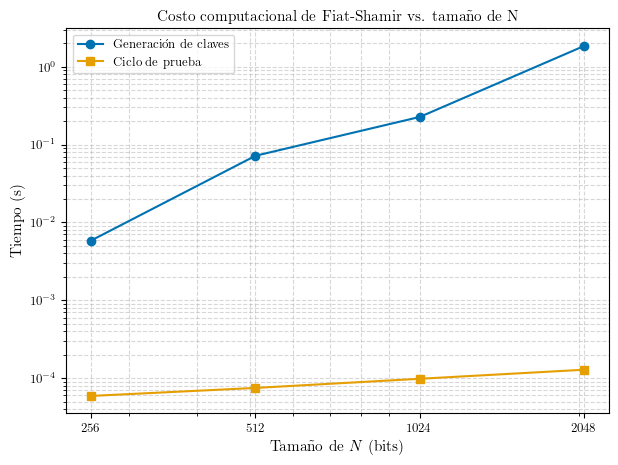

In [19]:
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter

plt.close('all')
plt.figure(figsize=(7,5))
plt.loglog(tamanos_bits, tiempos_keygen, marker='o', color="#0072B2", label="Generación de claves")
plt.loglog(tamanos_bits, tiempos_prueba, marker='s', color="#E69F00", label="Ciclo de prueba")

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(tamanos_bits))
ax.xaxis.set_major_formatter(FixedFormatter([str(b) for b in tamanos_bits]))
ax.xaxis.set_minor_formatter(NullFormatter())

plt.xlabel(r"Tamaño de $N$ (bits)")
plt.ylabel(r"Tiempo (s)")
plt.title("Costo computacional de Fiat-Shamir vs. tamaño de N")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.savefig("costo_computacional.png", dpi=300, bbox_inches="tight")
plt.show()


## Ejemplo aplicado — Parte B: análisis estadístico del hash (Monte Carlo)

La transformación Fiat-Shamir reemplaza el reto aleatorio del verificador por el resultado de una función hash. Se espera que el hash produzca retos indistinguibles de valores aleatorios.

Para estudiar esta propiedad utilizamos una simulación Monte Carlo. En cada iteración se genera un compromiso aleatorio independiente, se calcula su hash SHA-256 y se obtiene el reto como $$e = H(x) \bmod 2.$$

El experimento consiste en realizar 100 000 simulaciones independientes. Cada simulación ejecuta los siguientes pasos:

1. Generar un compromiso aleatorio.
2. Calcular su hash mediante SHA-256.
3. Obtener el reto como el bit menos significativo del hash.
4. Registrar si el reto obtenido es 0 o 1.

Bajo el supuesto de que SHA-256 se comporta como un oráculo aleatorio, se espera que ambos valores posibles aparezcan con probabilidad cercana a 0.5. Por ello, la estimación Monte Carlo de $P(e=0)$ debería converger hacia dicho valor conforme aumenta el número de simulaciones, de acuerdo con la Ley de los Grandes Números.

In [20]:
# Simulación Monte Carlo para estimar P(e = 0)

n_simulaciones = 100_000

conteo_ceros = 0
estimaciones = []
muestras = []

for i in range(n_simulaciones):
    compromiso = secrets.randbelow(2**256 + 1)
    e = calcular_reto_fiat_shamir(compromiso)

    if e == 0:
        conteo_ceros += 1

    # Guardar una estimación cada 100 simulaciones
    if (i + 1) % 100 == 0:
        muestras.append(i + 1)
        estimaciones.append(conteo_ceros / (i + 1))

print(f"Estimación final de P(e=0): {estimaciones[-1]:.5f}")

Estimación final de P(e=0): 0.50003


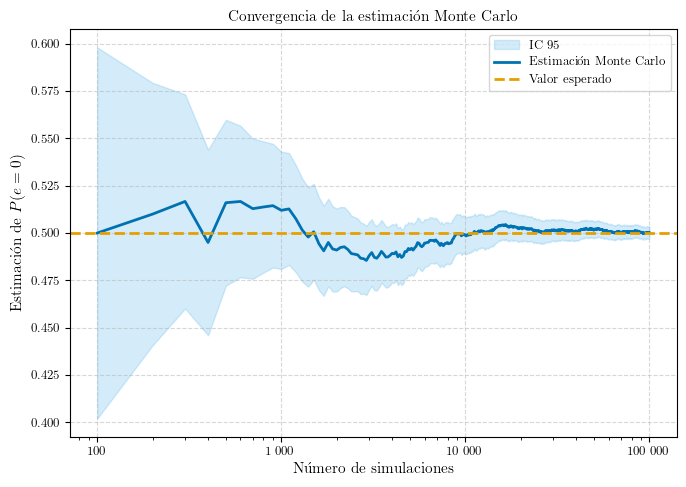

In [21]:
# Intervalos de confianza (95%)
estimaciones = np.array(estimaciones)
muestras = np.array(muestras)

error = 1.96 * np.sqrt(estimaciones * (1 - estimaciones) / muestras)

lim_inf = estimaciones - error
lim_sup = estimaciones + error

plt.figure(figsize=(7,5))

# Banda de confianza
plt.fill_between(
    muestras,
    lim_inf,
    lim_sup,
    color="#56B4E9",
    alpha=0.25,
    label="IC 95%"
)

# Estimación Monte Carlo
plt.plot(
    muestras,
    estimaciones,
    color="#0072B2",
    linewidth=2,
    label="Estimación Monte Carlo"
)

# Valor teórico
plt.axhline(
    0.5,
    color="#E69F00",
    linestyle="--",
    linewidth=2,
    label="Valor esperado"
)

plt.xscale("log")
plt.xticks([100, 1000, 10000, 100000],
           ["100", "1 000", "10 000", "100 000"])

plt.xlabel("Número de simulaciones")
plt.ylabel(r"Estimación de $P(e=0)$")

plt.title("Convergencia de la estimación Monte Carlo")

plt.grid(True, ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("monte_carlo_convergencia.png", dpi=300)
plt.show()